# AI-Based Movie Recommendation System

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Load Dataset

In [4]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")


In [22]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


## DATA UNDERSTANDING / EDA

In [23]:
movies.describe()

,movieId
count,9742.000000
mean,42200.353623
std,52160.494854
min,1.000000
25%,3248.250000
50%,7300.000000
75%,76232.000000
max,193609.000000


In [5]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [7]:
## checking null values
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [8]:
## top genres
movies['genres'].value_counts().head(10)

genres
Drama                   1053
Comedy                   946
Comedy|Drama             435
Comedy|Romance           363
Drama|Romance            349
Documentary              339
Comedy|Drama|Romance     276
Drama|Thriller           168
Horror                   167
Horror|Thriller          135
Name: count, dtype: int64

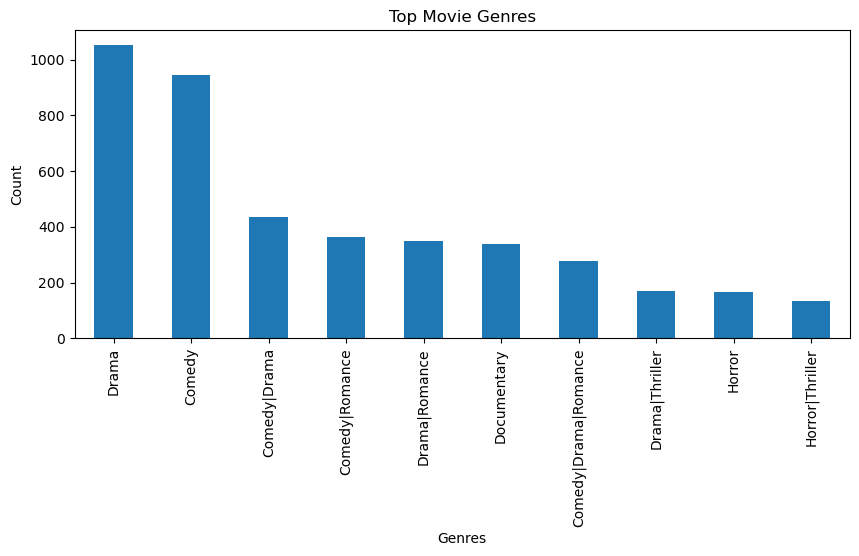

In [26]:
plt.figure(figsize=(10,4))

movies['genres'].value_counts().head(10).plot(kind='bar')

plt.title("Top Movie Genres")
plt.xlabel("Genres")
plt.ylabel("Count")

plt.show()                                                              ## helps detect trends

In [10]:
## some movies may have missing values. so we fill it with blank
movies['genres'] = movies['genres'].fillna('')

## Text Vectorization using TF-IDF

In [11]:
## converting texts into mathematical vectors
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(movies['genres'])

In [27]:
print(tfidf_matrix.shape)

(9742, 23)


## Cosine Similarity Calculation

In [12]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
## calculates similarity in movie types
## 0 -> completely different
## 1-> similar

## Movie Index Mapping

In [13]:
## index mapping
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

## Build Recommendation Engine

In [14]:
## building recommendation function
def recommend_movies(title, cosine_sim=cosine_sim):

    idx = indices[title]  # Find selected movie index.

    sim_scores = list(enumerate(cosine_sim[idx])) # Compare with all other movies.

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True) # Sort by similarity score.

    sim_scores = sim_scores[1:6]

    movie_indices = [i[0] for i in sim_scores]

    return movies['title'].iloc[movie_indices]  Return top 5 most similar movies.

## Testing Movie Recommendations

In [15]:
## testing model
recommend_movies('Toy Story (1995)')

1706                                       Antz (1998)
2355                                Toy Story 2 (1999)
2809    Adventures of Rocky and Bullwinkle, The (2000)
3000                  Emperor's New Groove, The (2000)
3568                             Monsters, Inc. (2001)
Name: title, dtype: object

In [17]:
recommend_movies('Batman Forever (1995)')

126                      Batman Forever (1995)
3511    It's a Mad, Mad, Mad, Mad World (1963)
4071                              I Spy (2002)
4726                    Nothing to Lose (1997)
6274                      Crime Busters (1977)
Name: title, dtype: object

In [18]:
recommend_movies('Jumanji (1995)')

53             Indian in the Cupboard, The (1995)
109             NeverEnding Story III, The (1994)
767               Escape to Witch Mountain (1975)
1514    Darby O'Gill and the Little People (1959)
1556                          Return to Oz (1985)
Name: title, dtype: object

In [19]:
recommend_movies('Heat (1995)')

22                      Assassins (1995)
138    Die Hard: With a Vengeance (1995)
156                      Net, The (1995)
249          Natural Born Killers (1994)
417                Judgment Night (1993)
Name: title, dtype: object

In [20]:
recommend_movies('GoldenEye (1995)')

84           Broken Arrow (1996)
378           Cliffhanger (1993)
431    Executive Decision (1996)
479    Surviving the Game (1994)
592             Rock, The (1996)
Name: title, dtype: object

In [21]:
recommend_movies('Sense and Sensibility (1995)')

24                Leaving Las Vegas (1995)
27                       Persuasion (1995)
42    How to Make an American Quilt (1995)
45            When Night Is Falling (1995)
66                     Bed of Roses (1996)
Name: title, dtype: object